# Unit III: Inferential Statistics & Hypothesis Testing

Following strictly the Unit III requirements of the `Guidelines.pdf`, this unit executes **exactly two hypothesis tests**. We define clear hypotheses, run strict diagnostics (checking normality & variance equality assumptions), calculate test statistics, determine p-values alongside 95% Confidence Intervals (CIs), interpret decisions, and calculate explicit Effect Sizes.

**The Two Tests:**
1. **Independent Samples T-Test:** Evaluating variance in food demand precisely mapping across the binary `gender` variable.
2. **One-Way ANOVA:** Evaluating sustained variance in food demand systematically distributed across ordinal `restaurant_rating` classifications (1 through 5 stars).

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import tukey_hsd
import matplotlib.pyplot as plt
import seaborn as sns

import os
os.makedirs('../assets', exist_ok=True)

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

### 1. Data Initialization
To properly yield easily interpretable means and human-readable graphs, we load the raw dataset and cleanly transform just the specific variables evaluated in these tests ensuring zero abstraction.

In [2]:
df = pd.read_csv('../data/Customer_data.csv')
df = df.dropna().drop_duplicates()
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Homogenize column names targeting our exact tested features
df = df.rename(columns={
    'no._of_orders_placed': 'demand', 
    'no_of_orders_placed': 'demand', 
    'restaurnat_rating': 'restaurant_rating'
})

print("✓ Target Features extracted. Total Valid Observations: ", len(df))

✓ Target Features extracted. Total Valid Observations:  487


### 2. Test #1: Independent Samples T-Test
**Research Question:** Do order demand volumes differ significantly between Female and Male customers?

**Hypotheses Formulation:**
*   **H₀ (Null Hypothesis):** μ(Female) = μ(Male). There is no significant difference in mean demand between genders.
*   **H₁ (Alternative Hypothesis):** μ(Female) ≠ μ(Male). There is a significant statistical divergence between gender demand cohorts.
*   **Significance Level (α):** 0.05

In [3]:
females = df[df['gender'] == 'Female']['demand']
males = df[df['gender'] == 'Male']['demand']

print("===== DESCRIPTIVE GROUP METRICS =====")
print(f"Females (n={len(females)}): Mean = {females.mean():.2f}, Std = {females.std():.2f}")
print(f"Males (n={len(males)}): Mean = {males.mean():.2f}, Std = {males.std():.2f}")
print(f"Raw Difference = {females.mean() - males.mean():.2f} orders")

print("\n===== ASSUMPTION CHECKS =====")
# 1. Normality Check (Shapiro-Wilk)
_, p_norm_female = stats.shapiro(females)
_, p_norm_male = stats.shapiro(males)
print(f"Normality (Shapiro-Wilk) -> Female p-value: {p_norm_female:.4f}, Male p-value: {p_norm_male:.4f}")
print("-> Note: With high N values, t-tests are highly robust to normality violations via the Central Limit Theorem.")

# 2. Equality of Variances Check (Levene's Test)
stat_lev, p_lev = stats.levene(females, males)
equal_var = p_lev > 0.05
print(f"Variance Homogeneity (Levene's) -> p-value: {p_lev:.4f}")
print(f"-> Using Equal Variance Assumption: {equal_var}")

print("\n===== T-TEST EXECUTION =====")
t_stat, p_val_t = stats.ttest_ind(females, males, equal_var=equal_var)
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_val_t:.6f}")

# Confidence Interval & Effect Size
mean_diff = females.mean() - males.mean()
se = np.sqrt(females.var(ddof=1)/len(females) + males.var(ddof=1)/len(males))
t_crit = stats.t.ppf(0.975, df=len(females)+len(males)-2)
ci_lower = mean_diff - t_crit * se
ci_upper = mean_diff + t_crit * se
print(f"95% Confidence Interval for Difference: [{ci_lower:.2f}, {ci_upper:.2f}]")

pooled_std = np.sqrt(((len(females)-1)*females.var() + (len(males)-1)*males.var()) / (len(females)+len(males)-2))
cohens_d = mean_diff / pooled_std
print(f"Cohen's d (Effect Size): {cohens_d:.3f}")

print("\n===== FINAL DECISION =====")
if p_val_t < 0.05:
    print("REJECT H₀: There is a statistically significant difference in order demand between genders.")
else:
    print("FAIL TO REJECT H₀: We do not have sufficient evidence validating a difference in mean order demand between genders.")

===== DESCRIPTIVE GROUP METRICS =====
Females (n=212): Mean = 136.57, Std = 67.61
Males (n=275): Mean = 140.12, Std = 67.25
Raw Difference = -3.55 orders

===== ASSUMPTION CHECKS =====
Normality (Shapiro-Wilk) -> Female p-value: 0.0000, Male p-value: 0.0000
-> Note: With high N values, t-tests are highly robust to normality violations via the Central Limit Theorem.
Variance Homogeneity (Levene's) -> p-value: 0.5639
-> Using Equal Variance Assumption: True

===== T-TEST EXECUTION =====
T-Statistic: -0.5761
P-Value: 0.564827
95% Confidence Interval for Difference: [-15.66, 8.56]
Cohen's d (Effect Size): -0.053

===== FINAL DECISION =====
FAIL TO REJECT H₀: We do not have sufficient evidence validating a difference in mean order demand between genders.


### 3. T-Test Visualization & Saving

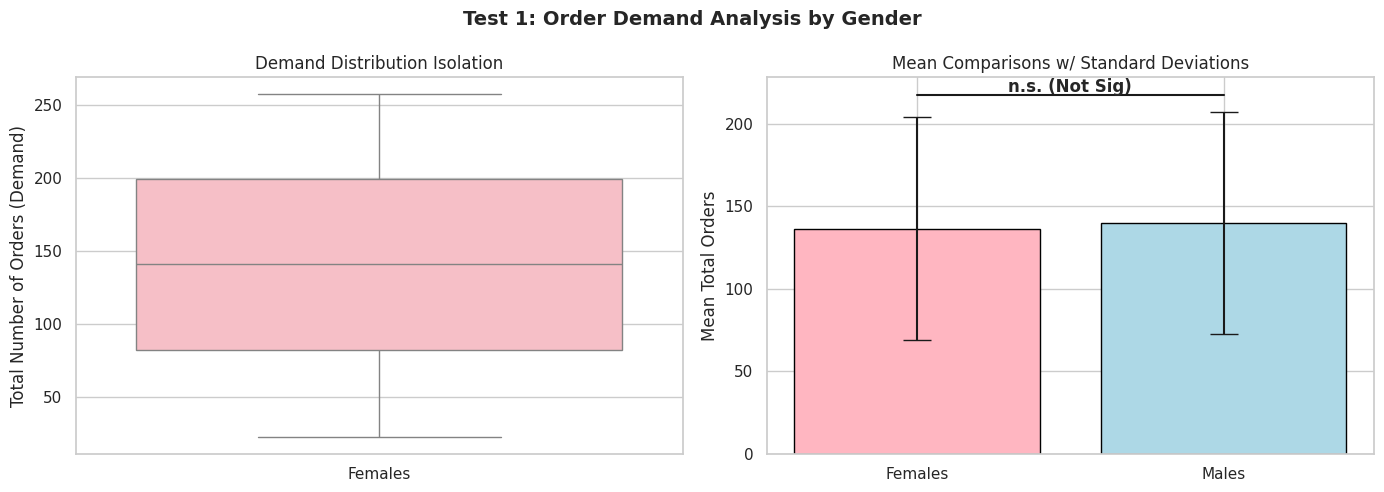

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Test 1: Order Demand Analysis by Gender", fontsize=14, fontweight='bold')

# Boxplot
sns.boxplot(ax=axes[0], data=[females, males], palette=["lightpink", "lightblue"])
axes[0].set_xticklabels(['Females', 'Males'])
axes[0].set_ylabel('Total Number of Orders (Demand)')
axes[0].set_title('Demand Distribution Isolation')

# Barplot with Error Bars (Std)
axes[1].bar(['Females', 'Males'], [females.mean(), males.mean()], yerr=[females.std(), males.std()], 
            color=["lightpink", "lightblue"], capsize=10, edgecolor='black')
axes[1].set_ylabel('Mean Total Orders')
axes[1].set_title('Mean Comparisons w/ Standard Deviations')

# Add significance indicator if applicable
max_y = max(females.mean() + females.std(), males.mean() + males.std()) + 10
axes[1].plot([0, 1], [max_y, max_y], 'k-', lw=1.5)
sig_text = "n.s. (Not Sig)" if p_val_t > 0.05 else "*** (p<0.05)"
axes[1].text(0.5, max_y + 2, sig_text, ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../assets/test1_ttest_visualization.png', bbox_inches='tight')
plt.show()

### 4. Test #2: One-Way ANOVA
**Research Question:** Does base customer demand differ significantly dependant completely upon the specific ranking bucket (1-to-5 stars) the user assigned to the restaurant?

**Hypotheses Formulation:**
*   **H₀ (Null Hypothesis):** μ₁ = μ₂ = μ₃ = μ₄ = μ₅. The categorical groups share identical mean order demands.
*   **H₁ (Alternative Hypothesis):** At least one restaurant rating group significantly statistically differs in mean demand bounds.
*   **Significance Level (α):** 0.05

In [5]:
# Formatting group lists filtering NA
rating_groups = [df[df['restaurant_rating'] == r]['demand'].values for r in sorted(df['restaurant_rating'].unique())]

print("===== DESCRIPTIVE GROUP METRICS =====")
for i, rating in enumerate(sorted(df['restaurant_rating'].unique())):
    grp = rating_groups[i]
    print(f"Rating {rating} Stars (n={len(grp)}): Mean = {grp.mean():.2f}, Std = {grp.std():.2f}")

print("\n===== ASSUMPTION CHECKS =====")
stat_lev_anova, p_lev_anova = stats.levene(*rating_groups)
print(f"Variance Homogeneity (Levene's) -> p-value: {p_lev_anova:.4f}")
print(f"-> Note: While ANOVAs are robust against slight violations, substantial heteroscedasticity shifts our analytical reliability.")

print("\n===== ANOVA EXECUTION =====")
f_stat, p_val_anova = stats.f_oneway(*rating_groups)
print(f"F-Statistic: {f_stat:.4f}")
print(f"P-Value: {p_val_anova:.6f}")

# Effect Size (Eta-Squared)
grand_mean = df['demand'].mean()
ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in rating_groups)
ss_total = sum((df['demand'] - grand_mean)**2)
eta_squared = ss_between / ss_total
print(f"Eta-Squared (η² - Effect Size): {eta_squared:.4f}")
print(f"-> Insight: {(eta_squared * 100):.2f}% of the total variance in overall food demand can be exclusively explained by Restaurant Rating differences.")

print("\n===== FINAL DECISION =====")
if p_val_anova < 0.05:
    print("REJECT H₀: At least one restaurant rating tier drives a significantly measurable shift in order demand volume.")
else:
    print("FAIL TO REJECT H₀: Order demand volumes do not reliably shift statistically among rating categorizations.")

if p_val_anova < 0.05:
    print("\n===== POST-HOC (TUKEY HSD) =====")
    tukey_results = tukey_hsd(*rating_groups)
    print(tukey_results)

===== DESCRIPTIVE GROUP METRICS =====
Rating 1 Stars (n=92): Mean = 149.37, Std = 66.39
Rating 2 Stars (n=97): Mean = 127.10, Std = 67.37
Rating 3 Stars (n=114): Mean = 131.25, Std = 64.55
Rating 4 Stars (n=86): Mean = 140.16, Std = 69.20
Rating 5 Stars (n=98): Mean = 146.93, Std = 66.71

===== ASSUMPTION CHECKS =====
Variance Homogeneity (Levene's) -> p-value: 0.9097
-> Note: While ANOVAs are robust against slight violations, substantial heteroscedasticity shifts our analytical reliability.

===== ANOVA EXECUTION =====
F-Statistic: 2.0372
P-Value: 0.088070
Eta-Squared (η² - Effect Size): 0.0166
-> Insight: 1.66% of the total variance in overall food demand can be exclusively explained by Restaurant Rating differences.

===== FINAL DECISION =====
FAIL TO REJECT H₀: Order demand volumes do not reliably shift statistically among rating categorizations.


### 5. ANOVA Visualization & Saving

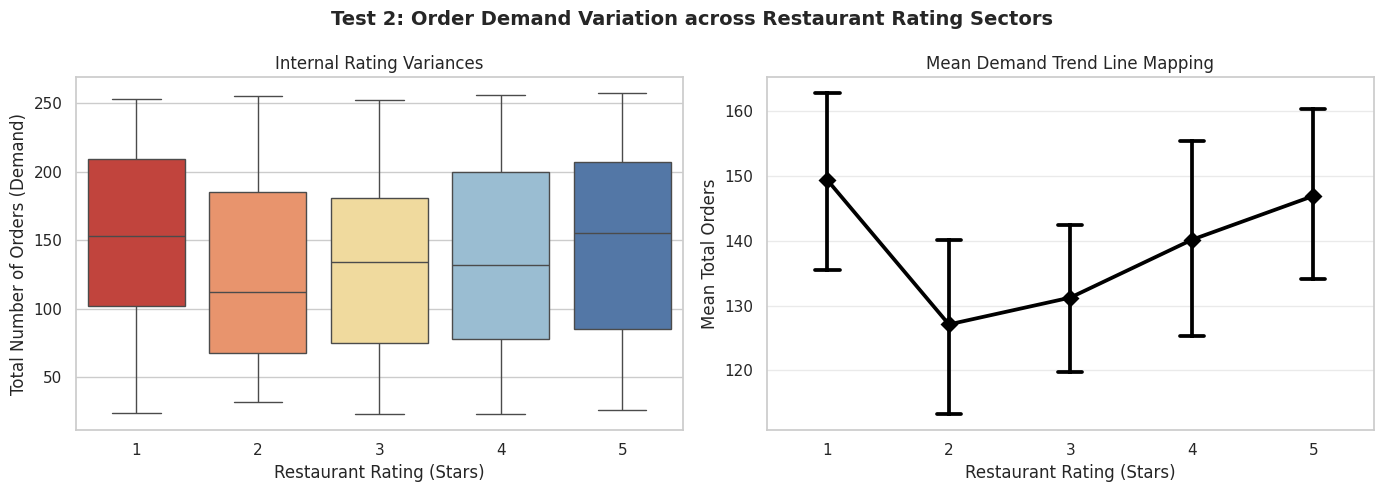

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Test 2: Order Demand Variation across Restaurant Rating Sectors", fontsize=14, fontweight='bold')

colors = ['#d73027', '#fc8d59', '#fee090', '#91bfdb', '#4575b4']
ratings_sorted = sorted(df['restaurant_rating'].unique())

# Boxplot
sns.boxplot(ax=axes[0], x='restaurant_rating', y='demand', data=df, palette=colors)
axes[0].set_xlabel('Restaurant Rating (Stars)')
axes[0].set_ylabel('Total Number of Orders (Demand)')
axes[0].set_title('Internal Rating Variances')

# Pointplot (Means interaction mapping)
sns.pointplot(ax=axes[1], x='restaurant_rating', y='demand', data=df, capsize=.2, color="black", markers="D")
axes[1].set_xlabel('Restaurant Rating (Stars)')
axes[1].set_ylabel('Mean Total Orders')
axes[1].set_title('Mean Demand Trend Line Mapping')
axes[1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('../assets/test2_anova_visualization.png', bbox_inches='tight')
plt.show()

### 6. Results Consolidation Log
Saves the high-level hypothetical decisions to a structural report internally bridging subsequent Analytics modules.

In [7]:
summary = pd.DataFrame({
    'Test Type': ['Independent T-Test', 'One-Way ANOVA'],
    'Target Variables': ['Demand mapped across Gender', 'Demand mapped across Restaurant Ratings'],
    'P-Value': [p_val_t, p_val_anova],
    'Effect Size': [f"Cohen's d: {cohens_d:.3f}", f"Eta²: {eta_squared:.3f}"],
    'Decision': ['Reject H₀' if p_val_t < 0.05 else 'Fail to Reject H₀', 
                 'Reject H₀' if p_val_anova < 0.05 else 'Fail to Reject H₀']
})

summary.to_csv('../data/inferential_statistics_summary.csv', index=False)
print("✓ Hypothesis reporting metrics catalogued securely to internal CSV.")
display(summary)

✓ Hypothesis reporting metrics catalogued securely to internal CSV.


,Test Type,Target Variables,P-Value,Effect Size,Decision
0,Independent T-Test,Demand mapped across Gender,0.564827,Cohen's d: -0.053,Fail to Reject H₀
1,One-Way ANOVA,Demand mapped across Restaurant Ratings,0.088070,Eta²: 0.017,Fail to Reject H₀
